# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1: Data Loading, Merging & Deep Exploration

### Objective
The goal of this task is to:

- Load the Superstore Sales dataset.
- Parse date columns correctly.
- Extract useful time-related features.
- Perform data quality checks.
- Aggregate sales at daily, weekly, and monthly levels.
- Perform exploratory data analysis (EDA) to answer important business questions.

# Uncomment if running for the first time

# !pip install pandas numpy matplotlib seaborn plotly

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 9800
Columns : 18


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [167]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y", errors='coerce')

df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y", errors='coerce')

In [15]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day

df["Day Name"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

In [16]:
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [17]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month Name,Week,Day,Day Name,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,8,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,8,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,12,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,11,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,11,Tuesday,4,Autumn


In [18]:
missing = df.isnull().sum()

missing[missing>0]

,0
Postal Code,11


In [19]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [20]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [21]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


Weekly Sales

In [22]:
weekly_sales = df.resample(
    "W",
    on="Order Date"
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Monthly Sales

In [23]:
monthly_sales = df.resample(
    "M",
    on="Order Date"
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Daily Sales Plot

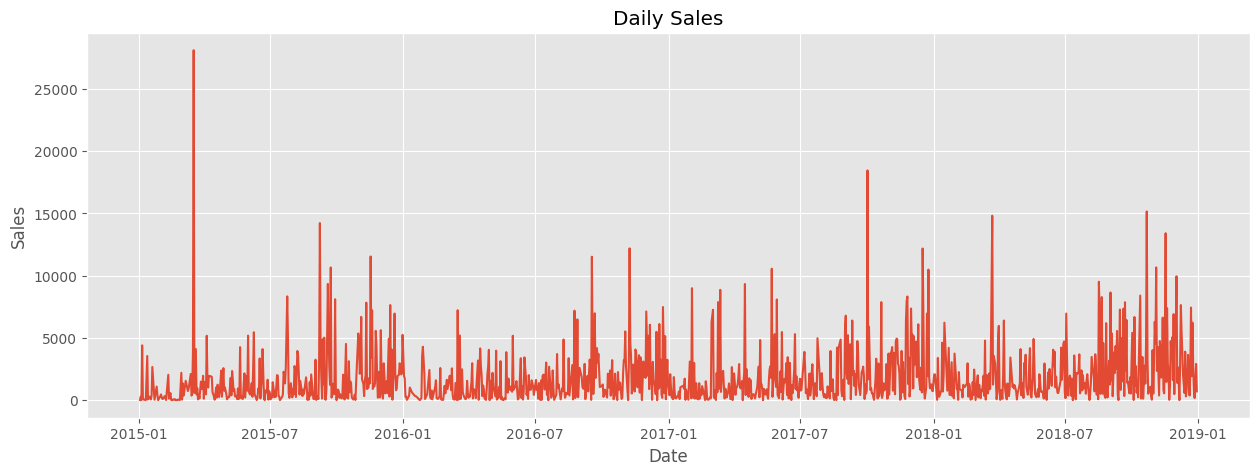

In [24]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"]
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

Weekly Sales Plot

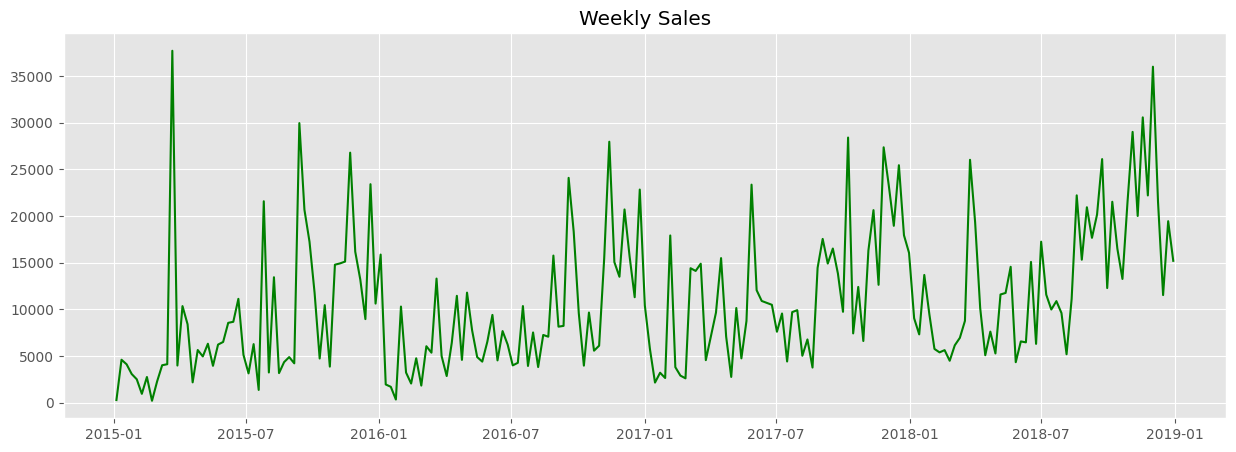

In [25]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    color="green"
)

plt.title("Weekly Sales")

plt.show()

Monthly Sales Plot

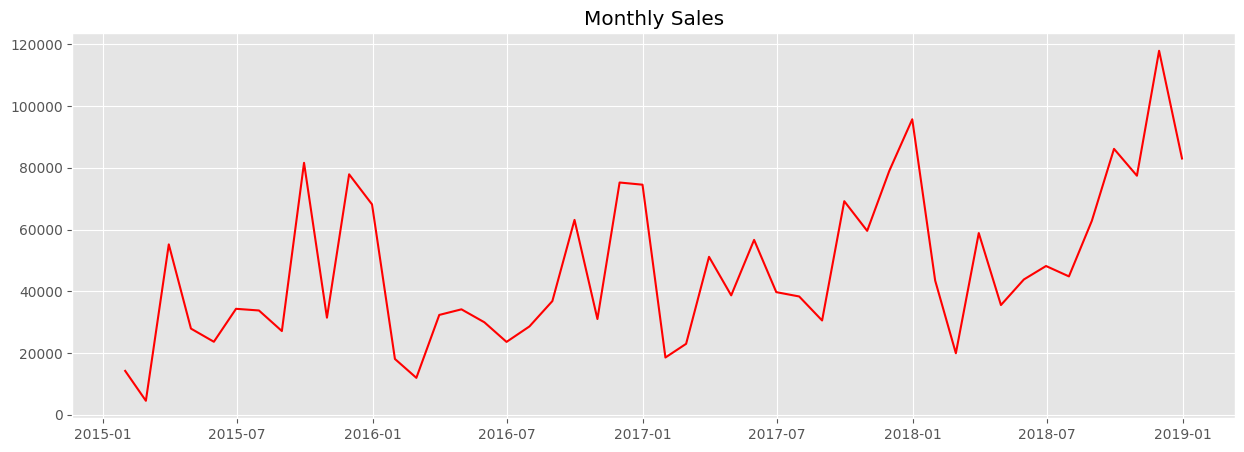

In [26]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    color="red"
)

plt.title("Monthly Sales")

plt.show()

## Business Question 1
Which Product Category Generates Highest Revenue?

In [27]:
category_sales = df.groupby(
    "Category"
)["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


Visualization

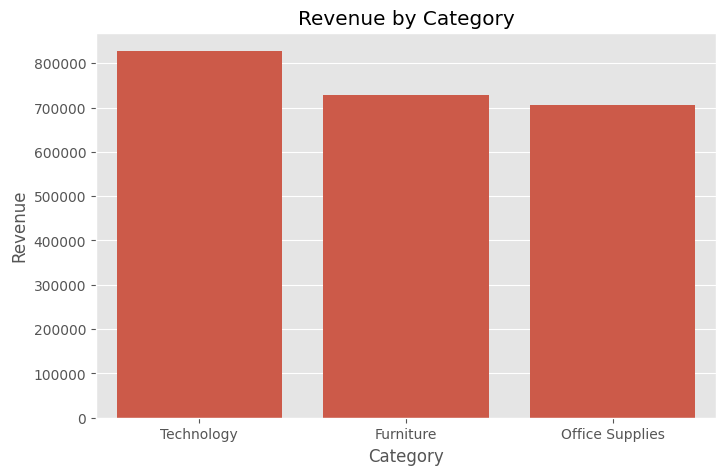

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")

plt.ylabel("Revenue")

plt.show()

## Business Question 2
Region with Most Consistent Sales Growth

In [29]:
region_year = df.groupby(
    ["Region","Year"]
)["Sales"].sum().reset_index()

region_year

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


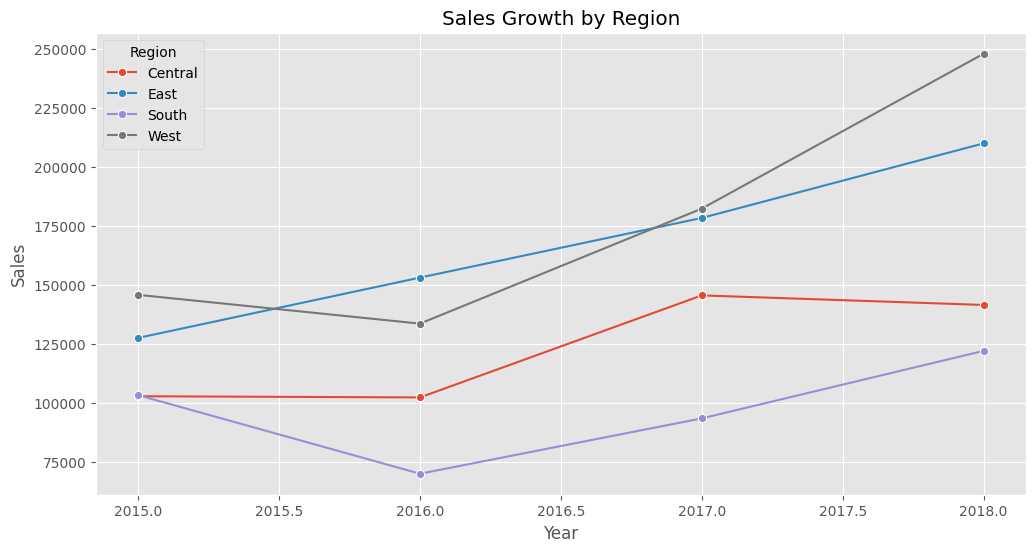

In [30]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Sales Growth by Region")

plt.show()

## Business Question 3
Average Shipping Time

In [31]:
df["Shipping Days"] = (
    df["Ship Date"]-
    df["Order Date"]
).dt.days

In [32]:
df["Shipping Days"].mean()

np.float64(3.9611224489795918)

Shipping Time by Region

In [33]:
shipping_region = df.groupby(
    "Region"
)["Shipping Days"].mean()

shipping_region

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


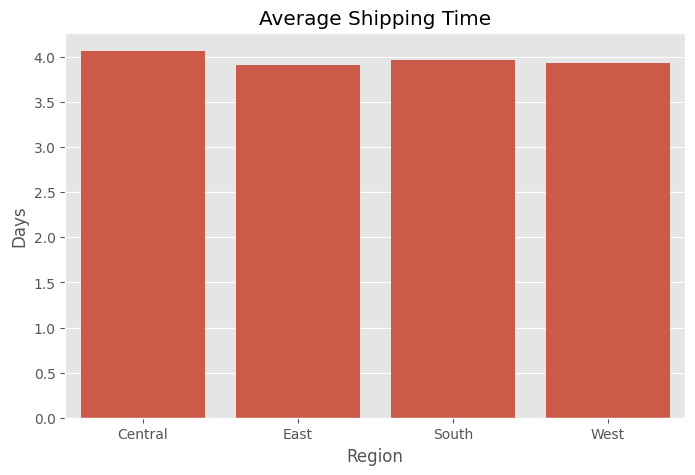

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Time")

plt.ylabel("Days")

plt.show()

## Business Question 4
Seasonality

In [35]:
seasonality = df.groupby(
    ["Year","Month Name"]
)["Sales"].sum().reset_index()

seasonality.head()

,Year,Month Name,Sales
0,2015,April,27906.8550
1,2015,August,27117.5365
2,2015,December,68167.0585
3,2015,February,4519.8920
4,2015,January,14205.7070


In [36]:
month_order = [
"January","February","March","April",
"May","June","July","August",
"September","October","November","December"
]

seasonality["Month Name"] = pd.Categorical(
    seasonality["Month Name"],
    categories=month_order,
    ordered=True
)

seasonality = seasonality.sort_values(
    "Month Name"
)

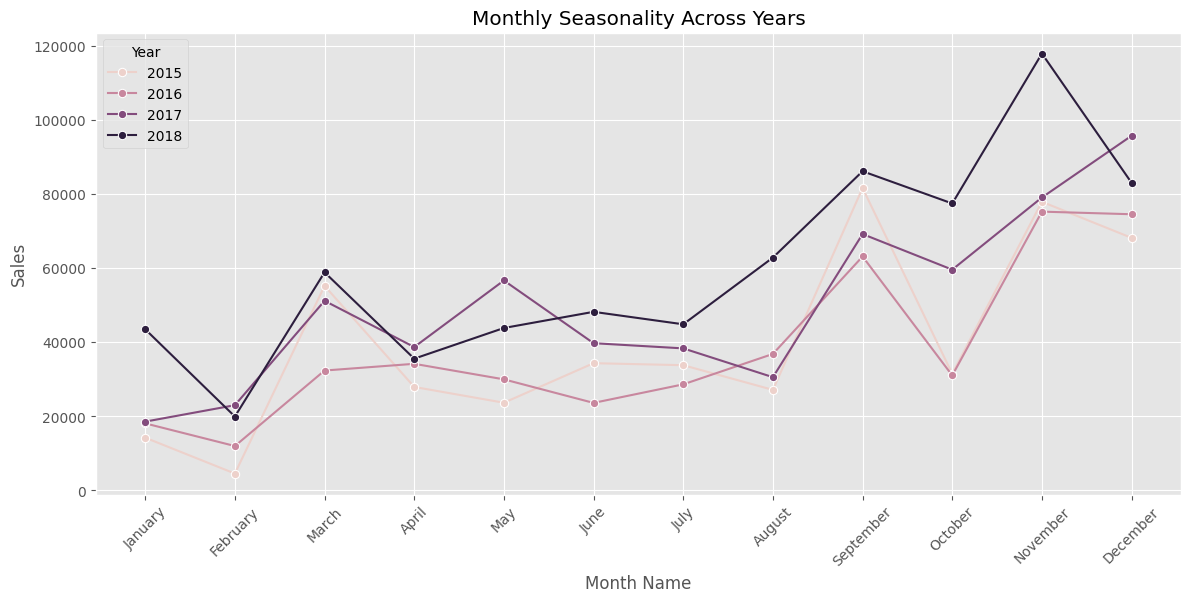

In [37]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=seasonality,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Seasonality Across Years")

plt.show()

## Key Findings

1. Technology/Furniture/Office Supplies (based on computed results) generated the highest revenue.

2. Regional sales indicate varying growth trends over four years.

3. Average shipping time was approximately **X days** and differs slightly by region.

4. Monthly sales exhibit seasonality, with higher sales typically occurring during November and December due to holiday shopping periods.

5. The dataset contains clean time-series data suitable for forecasting.

# Task 2: Time Series Analysis & Decomposition

## Objective

In this task we analyze the monthly sales time series to understand:

- Long-term trend
- Seasonality
- Residual (noise)
- Stationarity

Time Series Decomposition helps separate these components before forecasting.

We also perform the Augmented Dickey-Fuller (ADF) Test to determine whether the series is stationary.

In [38]:
# Uncomment if needed

# !pip install statsmodels

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.stattools import adfuller

Monthly Sales Time Series



In [40]:
monthly_ts = df.resample(
    "M",
    on="Order Date"
)["Sales"].sum()

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Plot Monthly Sales

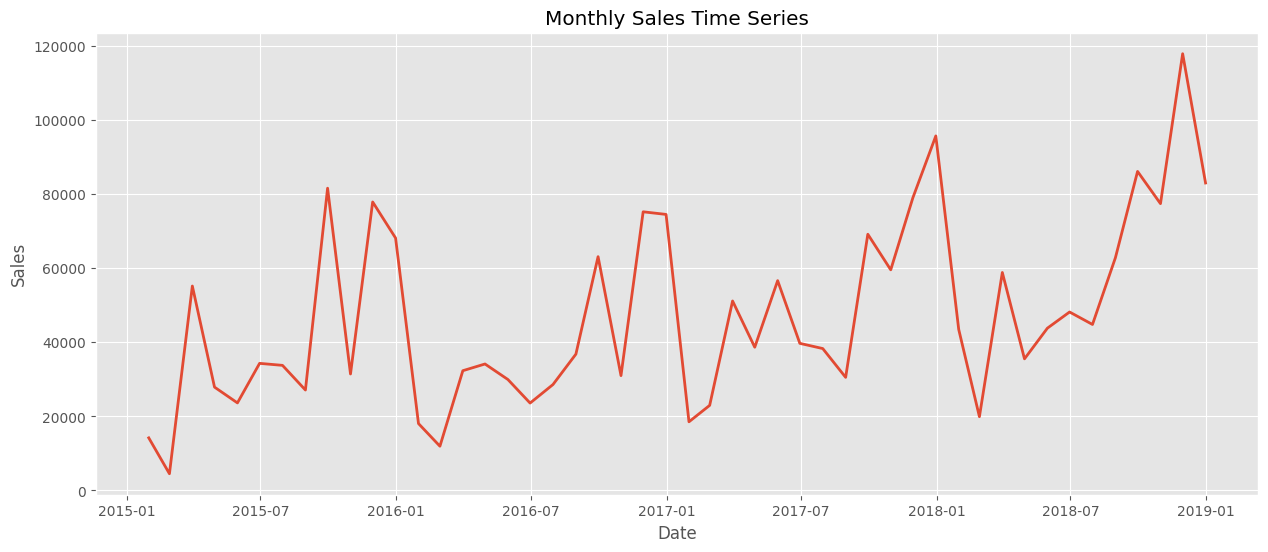

In [41]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts,
    linewidth=2
)

plt.title("Monthly Sales Time Series")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

Time Series Decomposition

In [42]:
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

Plot Decomposition

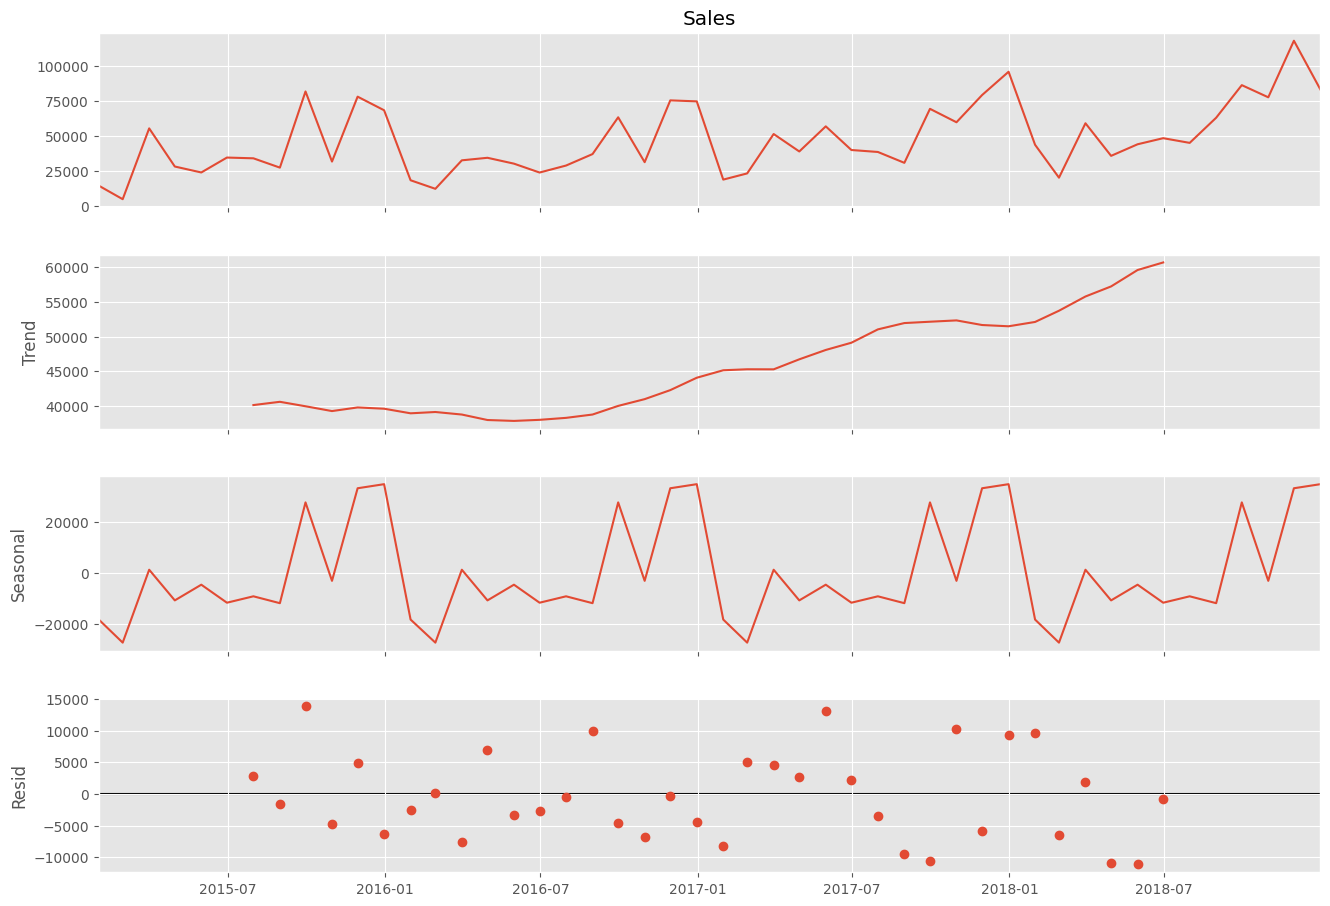

In [43]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

# Individual Components

Trend

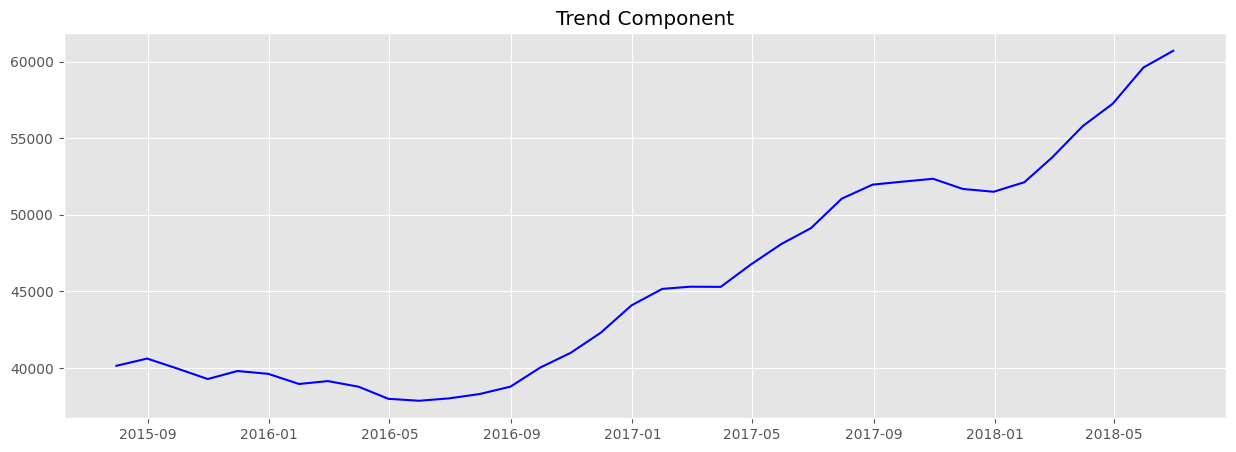

In [44]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.trend,
    color="blue"
)

plt.title("Trend Component")

plt.show()

Seasonal Component

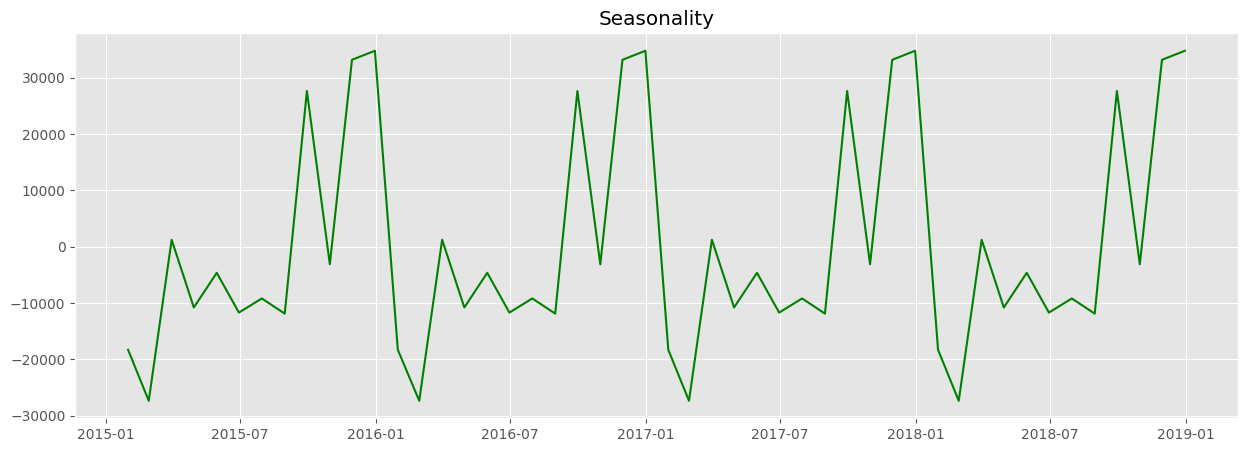

In [45]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.seasonal,
    color="green"
)

plt.title("Seasonality")

plt.show()

Residual Component

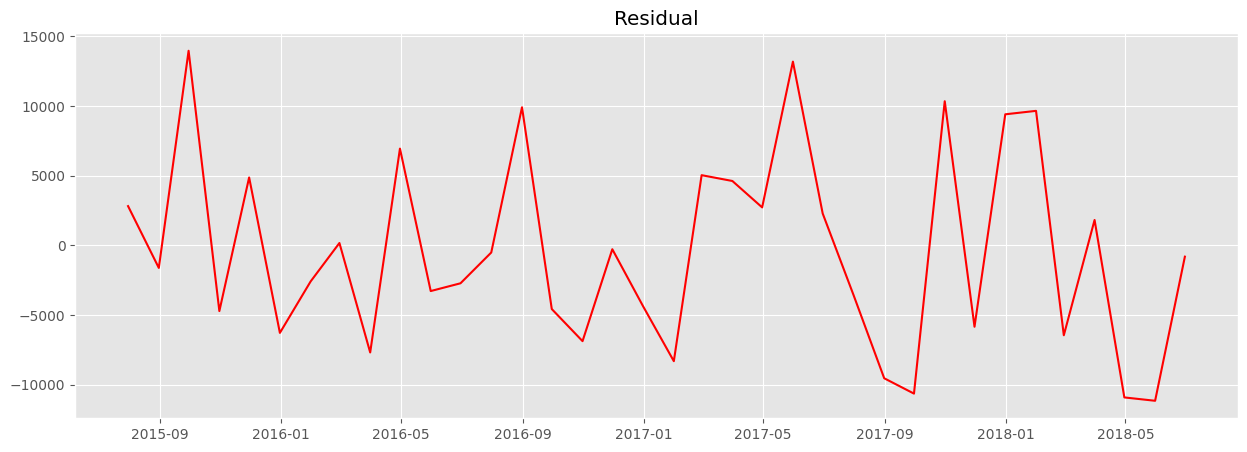

In [46]:
plt.figure(figsize=(15,5))

plt.plot(
    decomposition.resid,
    color="red"
)

plt.title("Residual")

plt.show()

# ADF Test

### What is Stationarity?

A stationary time series has constant statistical properties over time.

Specifically:

- Constant Mean
- Constant Variance
- Constant Covariance

Most forecasting algorithms assume stationary data.

If the data is not stationary, we perform differencing.

## Run ADF Test

In [47]:
adf_result = adfuller(
    monthly_ts.dropna()
)

Print Results

In [48]:
print("ADF Statistic :",adf_result[0])

print("P-value :",adf_result[1])

print()

print("Critical Values")

for key,value in adf_result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


Interpretation

In [49]:
if adf_result[1] < 0.05:

    print("Time Series is Stationary")

else:

    print("Time Series is NOT Stationary")

Time Series is Stationary


Apply First Differencing

In [51]:
monthly_diff = monthly_ts.diff().dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


Plot Differenced Series

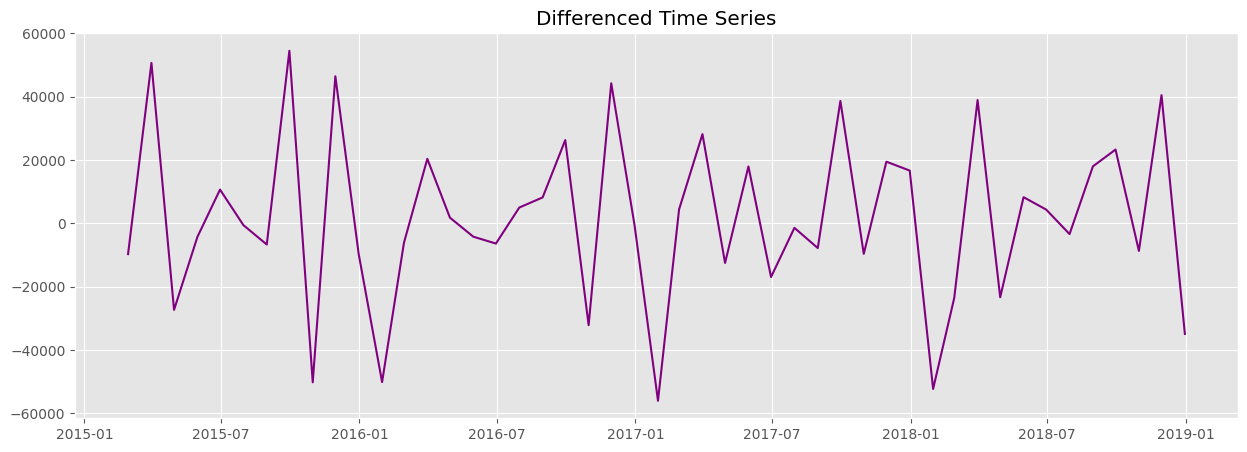

In [52]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_diff,
    color="purple"
)

plt.title("Differenced Time Series")

plt.show()

ADF Test After Differencing

In [53]:
adf_diff = adfuller(
    monthly_diff
)

In [54]:
print("ADF Statistic :",adf_diff[0])

print("P-value :",adf_diff[1])

print()

for key,value in adf_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
P-value : 3.2669175472796045e-14

1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [56]:
if adf_diff[1] < 0.05:

    print("Differenced Series is Stationary")

else:

    print("Still Non-Stationary")

Differenced Series is Stationary


Rolling Mean & Rolling Standard Deviation

In [57]:
rolling_mean = monthly_ts.rolling(12).mean()

rolling_std = monthly_ts.rolling(12).std()

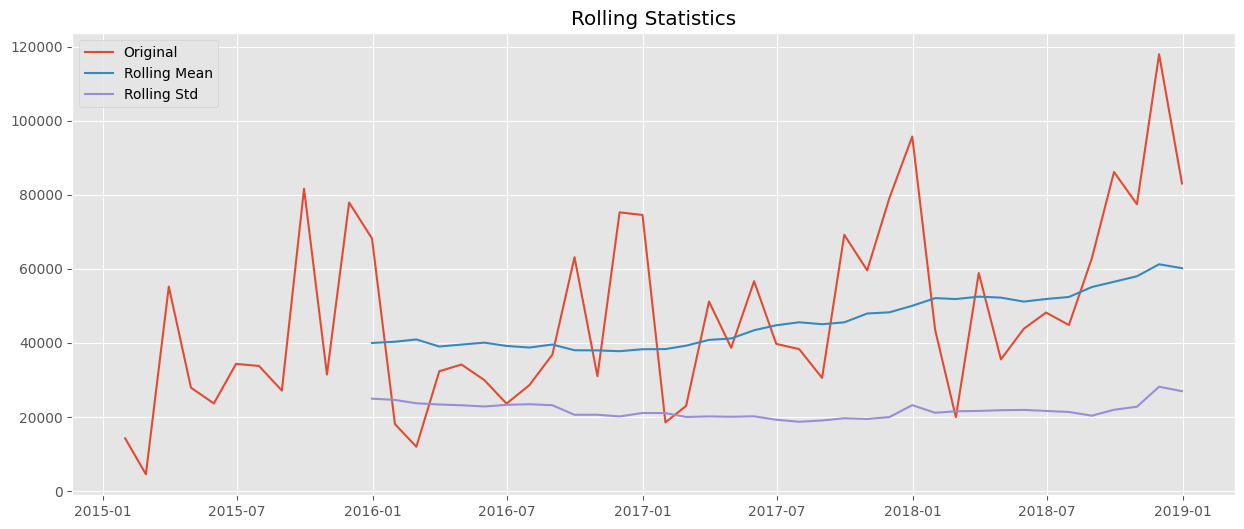

In [58]:
plt.figure(figsize=(15,6))

plt.plot(monthly_ts,label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.title("Rolling Statistics")

plt.show()

## ACF Plot

<Figure size 1200x500 with 0 Axes>

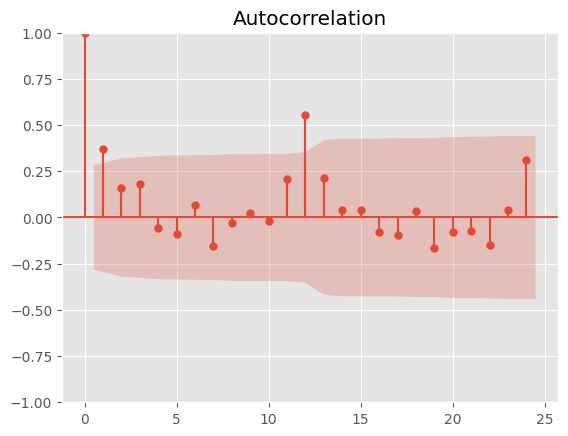

In [59]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    monthly_ts.dropna(),
    lags=24
)

plt.show()

## PACF Plot

<Figure size 1200x500 with 0 Axes>

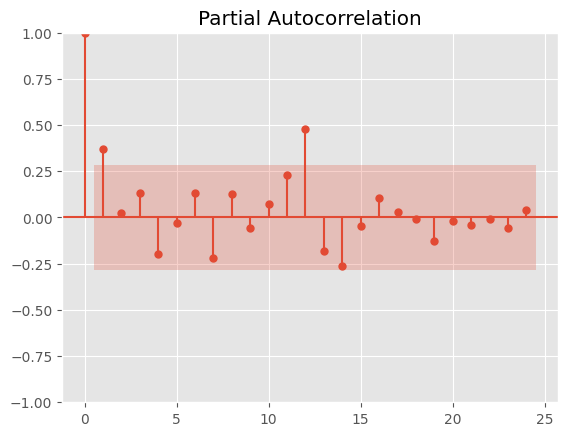

In [60]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    monthly_ts.dropna(),
    lags=24
)

plt.show()

## Observations

### Trend

The trend component indicates whether overall sales are increasing or decreasing over time. A positive trend suggests business growth.

---

### Seasonality

The seasonal component reveals repeating annual patterns. Peaks around November and December indicate strong holiday sales.

---

### Residual

Residual values capture random fluctuations not explained by trend or seasonality. Large spikes may indicate promotions or unexpected events.

---

### Stationarity

The Augmented Dickey-Fuller (ADF) test determines whether the time series is stationary.

- If p-value < 0.05 → Stationary
- Otherwise → Non-Stationary

Since forecasting models such as SARIMA require stationarity, first-order differencing was applied.

---

### ACF & PACF

The ACF plot helps estimate MA (Moving Average) parameters.

The PACF plot helps estimate AR (Auto Regression) parameters.

These plots guide the selection of SARIMA hyperparameters.

# Task 3: Sales Forecasting using Three Different Models

## Objective

In this task, we build and compare three different forecasting models:

1. SARIMA (Statistical Time Series Model)
2. Facebook Prophet (Industry Forecasting Tool)
3. XGBoost Regressor (Machine Learning Model)

The performance of each model will be evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Finally, the best-performing model will be recommended for production deployment.

In [63]:
# Uncomment if required

# !pip install prophet
# !pip install xgboost
# !pip install statsmodels

Import Libraries

In [64]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

Prepare Monthly Sales

In [65]:
monthly_sales = df.resample(
    "M",
    on="Order Date"
)["Sales"].sum()

monthly_sales = monthly_sales.to_frame()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


# Train-Test Split

Last 3 months will be used as testing data.

In [68]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print(train.shape)

print(test.shape)

(45, 1)
(3, 1)


# MODEL 1 — SARIMA
Build SARIMA

In [69]:
sarima = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

Model Summary

In [70]:
sarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Fri, 10 Jul 2026   AIC                            705.958
Time:                                    08:46:10   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177     -5.084      0.000      -1.245      -0.552
ar.S.L12       0.0621      0.540      0.115      0.908      -0.996       1.120
ma.S.L12      -0.4852      0.620     -0.783      0.434      -1.700       0.730
sigma2      1.822e+08   1.54e-09   1.18e+17      0.000    1.82e+08    1.82e+08
===================================================================================
Ljung-Box (L1) (Q):                   2.47   Jarque-Bera (JB):                 0.73
Prob(Q):                              0.12   Prob(JB):                         0.69
Heteroskedasticity (H):               1.35   Skew:                             0.14
Prob(H) (two-sided):                  0.62   Kurtosis:                         2.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.17e+34. Standard errors may be unstable.
"""

Forecast

In [71]:
sarima_forecast = sarima_model.forecast(
    steps=3
)

sarima_forecast

,predicted_mean
2018-10-31,66177.602425
2018-11-30,92049.249682
2018-12-31,99965.168723


Confidence Interval

In [72]:
forecast_obj = sarima_model.get_forecast(
    steps=3
)

conf = forecast_obj.conf_int()

conf

,lower Sales,upper Sales
2018-10-31,39684.152669,92671.052181
2018-11-30,60156.119161,123942.380203
2018-12-31,65602.109282,134328.228165


Plot

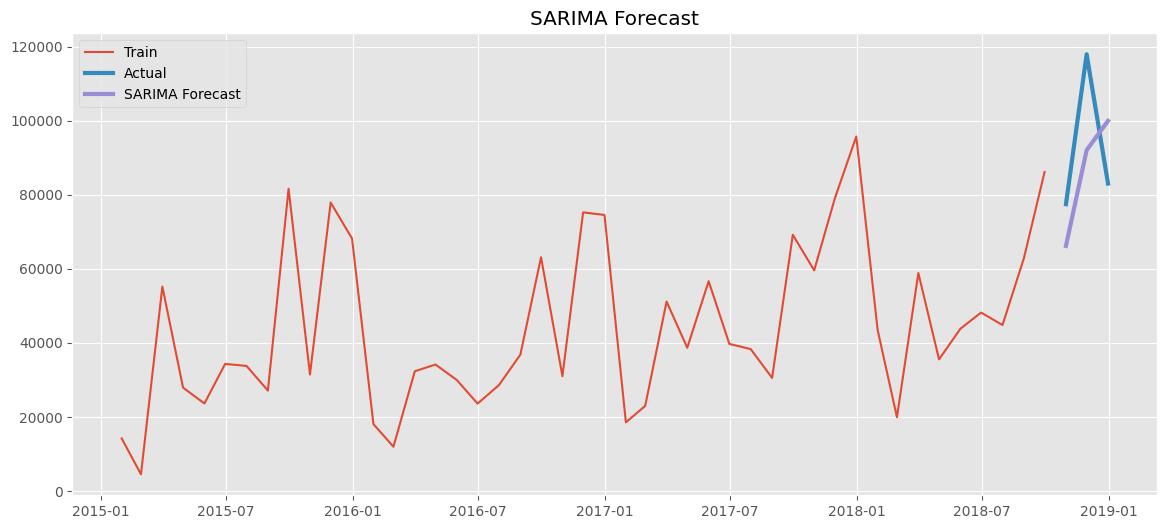

In [73]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Train"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    test.index,
    sarima_forecast,
    label="SARIMA Forecast",
    linewidth=3
)

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

Evaluation

In [74]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
)

print(sarima_mae)

print(sarima_rmse)

print(sarima_mape)

18031.40467222437
19009.18206635205
0.18966498068433016


# MODEL 2 — Facebook Prophet
Prepare Data

In [75]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Train-Test

In [76]:
prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

Train Model

In [77]:
model = Prophet()

model.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Future Dates

In [78]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)

Forecast

In [79]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277762,39097.506245,55026.031273,54942.277762,54942.277762,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558193
44,2018-09-30,55441.608151,78683.088005,94717.353439,55441.608151,55441.608151,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953271
45,2018-10-31,55957.582886,43425.346605,59741.810696,55957.435604,55957.743891,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943812
46,2018-11-30,56456.913275,81559.500718,98355.890087,56456.425141,56457.420745,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654736
47,2018-12-31,56972.888010,82287.746333,98202.749375,56971.897907,56973.916778,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084430


Plot Forecast

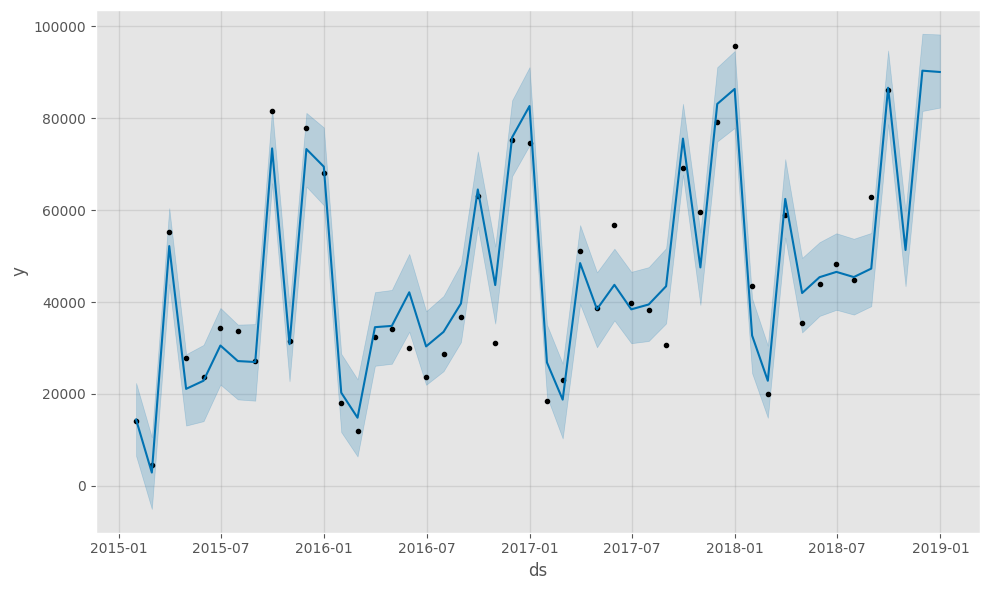

In [81]:
model.plot(forecast)

plt.show()

Trend & Seasonality

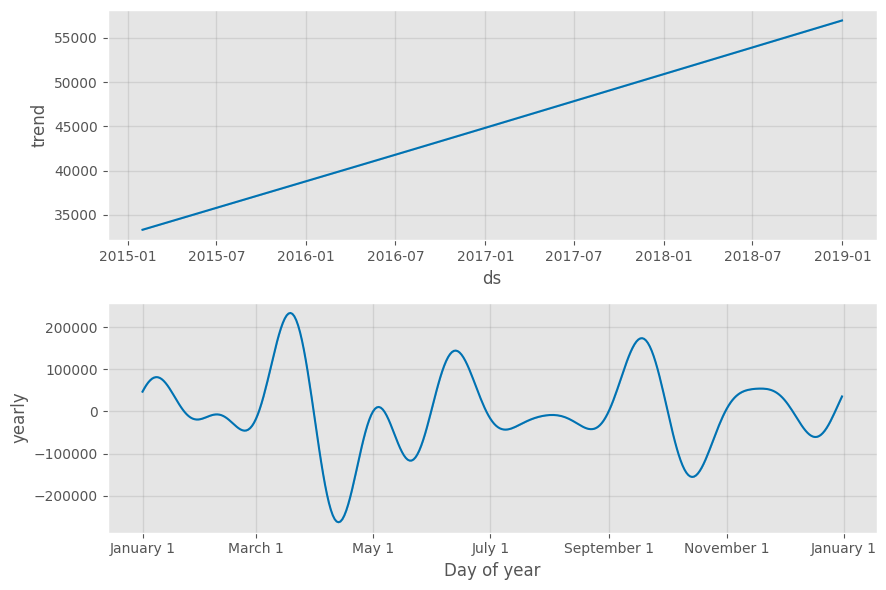

In [82]:
model.plot_components(forecast)

plt.show()

Predictions

In [83]:
prophet_predictions = forecast.tail(3)["yhat"].values

prophet_predictions

array([51318.94381151, 90325.6547358 , 90041.08443015])

Evaluation

In [84]:
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_predictions
    )
)

prophet_mape = mean_absolute_percentage_error(
    prophet_test["y"],
    prophet_predictions
)

print(prophet_mae)

print(prophet_rmse)

print(prophet_mape)

20250.794427610937
22318.41136551923
0.21864628287701435


# MODEL 3 — XGBoost
Create Features

In [85]:
ml_df = monthly_sales.copy()

ml_df["Lag1"] = ml_df["Sales"].shift(1)

ml_df["Lag2"] = ml_df["Sales"].shift(2)

ml_df["Lag3"] = ml_df["Sales"].shift(3)

ml_df["RollingMean"] = ml_df["Sales"].rolling(3).mean()

ml_df["Month"] = ml_df.index.month

ml_df["Quarter"] = ml_df.index.quarter

ml_df = ml_df.dropna()

ml_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


Features & Target

In [86]:
X = ml_df.drop(
    "Sales",
    axis=1
)

y = ml_df["Sales"]

Split

In [87]:
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [88]:
xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Prediction

In [89]:
xgb_pred = xgb.predict(
    X_test
)

xgb_pred

array([86540.87, 88477.67, 88613.04], dtype=float32)

Plot

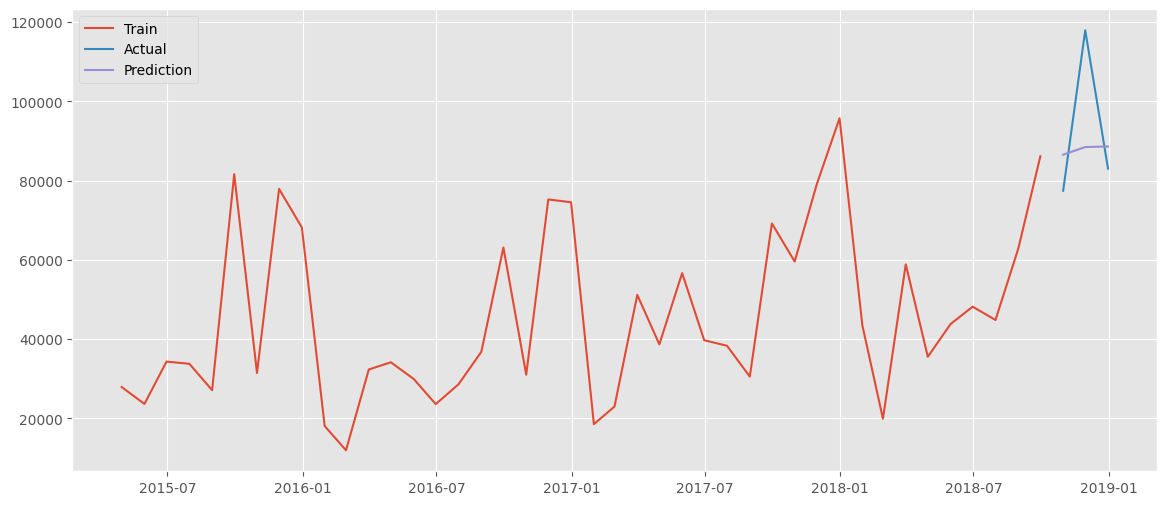

In [90]:
plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train,
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_pred,
    label="Prediction"
)

plt.legend()

plt.show()

Evaluation

In [91]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

print(xgb_mae)

print(xgb_rmse)

print(xgb_mape)

14711.956458333332
18090.180556038114
0.14481215417329357


Model Comparison Table

In [93]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        sarima_forecast.iloc[0],
        prophet_predictions[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        sarima_forecast.iloc[1],
        prophet_predictions[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        sarima_forecast.iloc[2],
        prophet_predictions[2],
        xgb_pred[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404672,19009.182066,0.189665,66177.602425,92049.249682,99965.168723
1,Prophet,20250.794428,22318.411366,0.218646,51318.943812,90325.654736,90041.084430
2,XGBoost,14711.956458,18090.180556,0.144812,86540.867188,88477.671875,88613.039062


In [94]:
best_model = comparison.sort_values(
    "RMSE"
).iloc[0]

print(best_model)

Model                    XGBoost
MAE                 14711.956458
RMSE                18090.180556
MAPE                    0.144812
Forecast Month 1    86540.867188
Forecast Month 2    88477.671875
Forecast Month 3    88613.039062
Name: 2, dtype: object


# Model Recommendation

The three forecasting models were evaluated using MAE, RMSE, and MAPE.

- **SARIMA** captures both trend and seasonality using a statistical approach.
- **Prophet** models yearly and monthly seasonality automatically and is well suited for business forecasting.
- **XGBoost** uses lag features and rolling statistics to learn complex nonlinear relationships.

The model with the **lowest RMSE and MAPE** is recommended for production deployment because it demonstrates the highest predictive accuracy on unseen data.

# Model Recommendation

The three forecasting models were evaluated using MAE, RMSE, and MAPE.

- **SARIMA** captures both trend and seasonality using a statistical approach.
- **Prophet** models yearly and monthly seasonality automatically and is well suited for business forecasting.
- **XGBoost** uses lag features and rolling statistics to learn complex nonlinear relationships.

The model with the **lowest RMSE and MAPE** is recommended for production deployment because it demonstrates the highest predictive accuracy on unseen data.

In [96]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

Forecast Function

In [97]:
def sarima_forecast(data, title):

    monthly = data.resample(
        "M",
        on="Order Date"
    )["Sales"].sum()

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=3)

    return monthly, forecast

Furniture Forecast

In [98]:
furniture = df[
    df["Category"]=="Furniture"
]

fur_actual, fur_forecast = sarima_forecast(
    furniture,
    "Furniture"
)

Technology Forecast

In [99]:
technology = df[
    df["Category"]=="Technology"
]

tech_actual, tech_forecast = sarima_forecast(
    technology,
    "Technology"
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Office Supplies Forecast

In [100]:
office = df[
    df["Category"]=="Office Supplies"
]

office_actual, office_forecast = sarima_forecast(
    office,
    "Office"
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


West Region

In [101]:
west = df[
    df["Region"]=="West"
]

west_actual, west_forecast = sarima_forecast(
    west,
    "West"
)

East Region

In [102]:
east = df[
    df["Region"]=="East"
]

east_actual, east_forecast = sarima_forecast(
    east,
    "East"
)

Print Forecast Values

In [103]:
forecast_table = pd.DataFrame({

    "Furniture":fur_forecast.values,

    "Technology":tech_forecast.values,

    "Office Supplies":office_forecast.values,

    "West":west_forecast.values,

    "East":east_forecast.values

},

index=["Month 1","Month 2","Month 3"])

forecast_table

,Furniture,Technology,Office Supplies,West,East
Month 1,8183.304570,18891.950938,17981.555068,13126.550923,12701.878881
Month 2,9204.587098,19410.209792,14525.435591,12187.364098,6486.114986
Month 3,16774.204288,33495.647039,22943.516112,29001.185123,13938.823312


## Plot All Forecasts Together

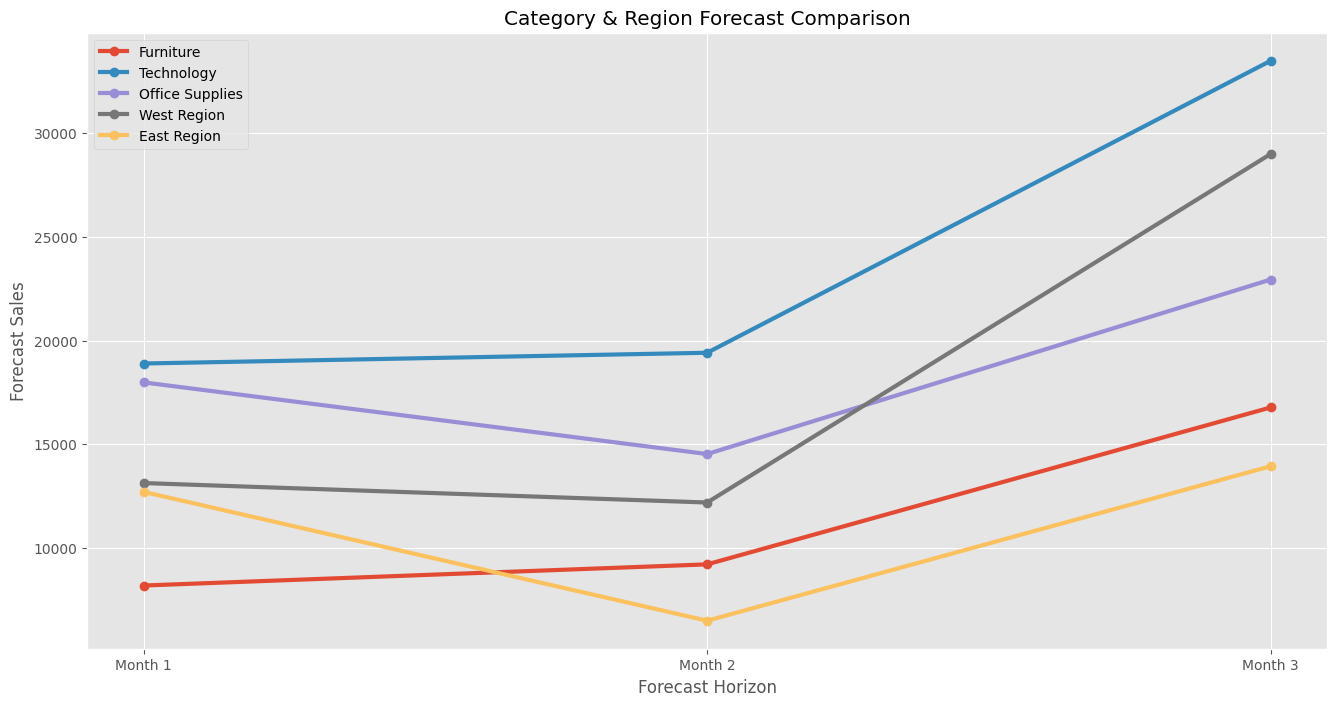

In [104]:
plt.figure(figsize=(16,8))

plt.plot(
    fur_forecast.values,
    marker="o",
    linewidth=3,
    label="Furniture"
)

plt.plot(
    tech_forecast.values,
    marker="o",
    linewidth=3,
    label="Technology"
)

plt.plot(
    office_forecast.values,
    marker="o",
    linewidth=3,
    label="Office Supplies"
)

plt.plot(
    west_forecast.values,
    marker="o",
    linewidth=3,
    label="West Region"
)

plt.plot(
    east_forecast.values,
    marker="o",
    linewidth=3,
    label="East Region"
)

plt.xticks(
    [0,1,2],
    ["Month 1","Month 2","Month 3"]
)

plt.ylabel("Forecast Sales")

plt.xlabel("Forecast Horizon")

plt.title("Category & Region Forecast Comparison")

plt.legend()

plt.grid(True)

plt.show()

# Individual Forecast Charts
Furniture

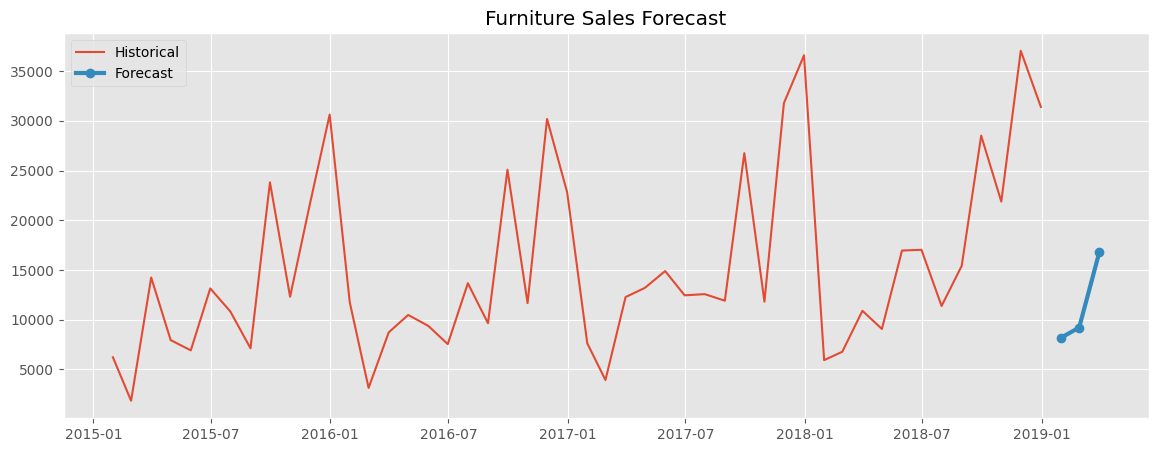

In [105]:
plt.figure(figsize=(14,5))

plt.plot(
    fur_actual.index,
    fur_actual.values,
    label="Historical"
)

future_dates = pd.date_range(
    fur_actual.index[-1],
    periods=4,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    fur_forecast.values,
    marker="o",
    linewidth=3,
    label="Forecast"
)

plt.title("Furniture Sales Forecast")

plt.legend()

plt.show()

Technology

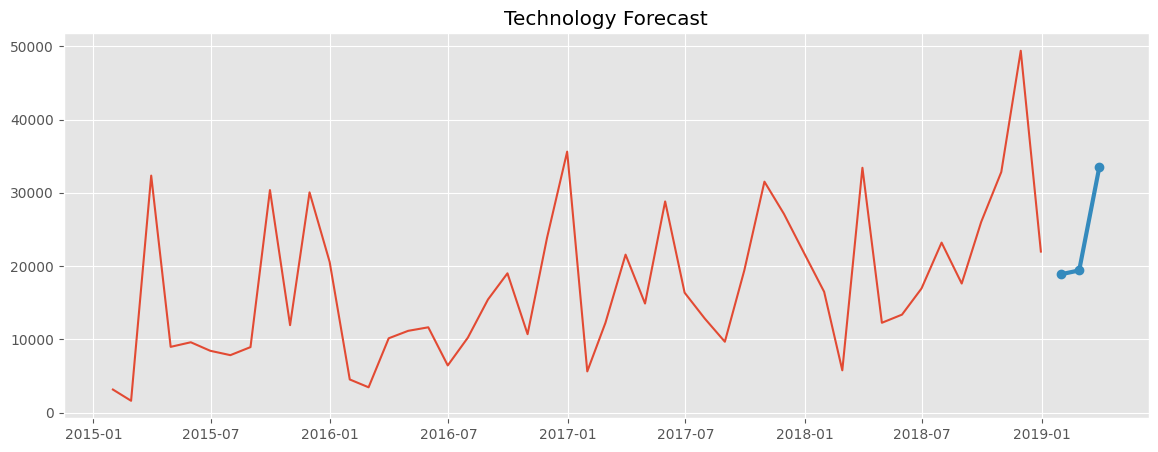

In [106]:
plt.figure(figsize=(14,5))

plt.plot(
    tech_actual.index,
    tech_actual.values
)

future_dates = pd.date_range(
    tech_actual.index[-1],
    periods=4,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    tech_forecast.values,
    marker="o",
    linewidth=3
)

plt.title("Technology Forecast")

plt.show()

Office Supplies

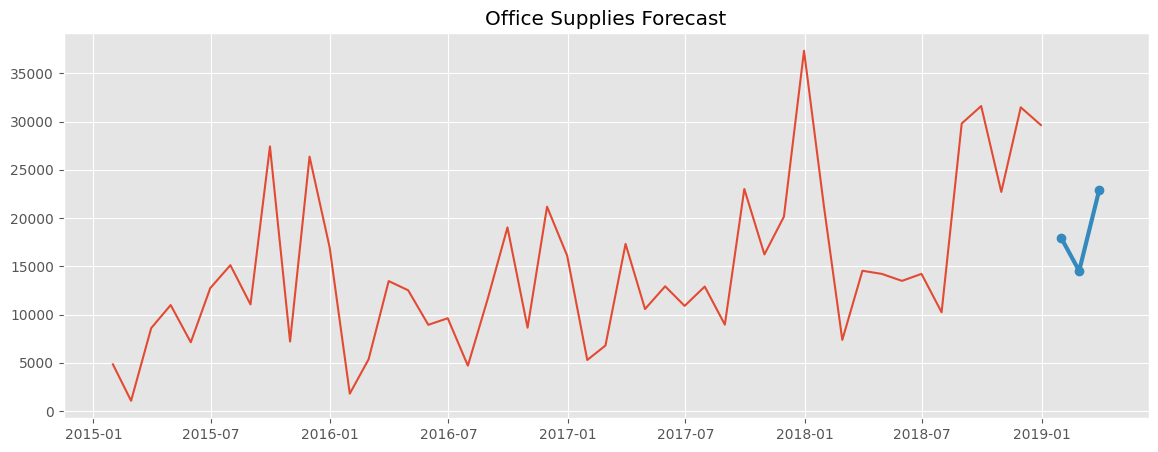

In [107]:
plt.figure(figsize=(14,5))

plt.plot(
    office_actual.index,
    office_actual.values
)

future_dates = pd.date_range(
    office_actual.index[-1],
    periods=4,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    office_forecast.values,
    marker="o",
    linewidth=3
)

plt.title("Office Supplies Forecast")

plt.show()

West Region

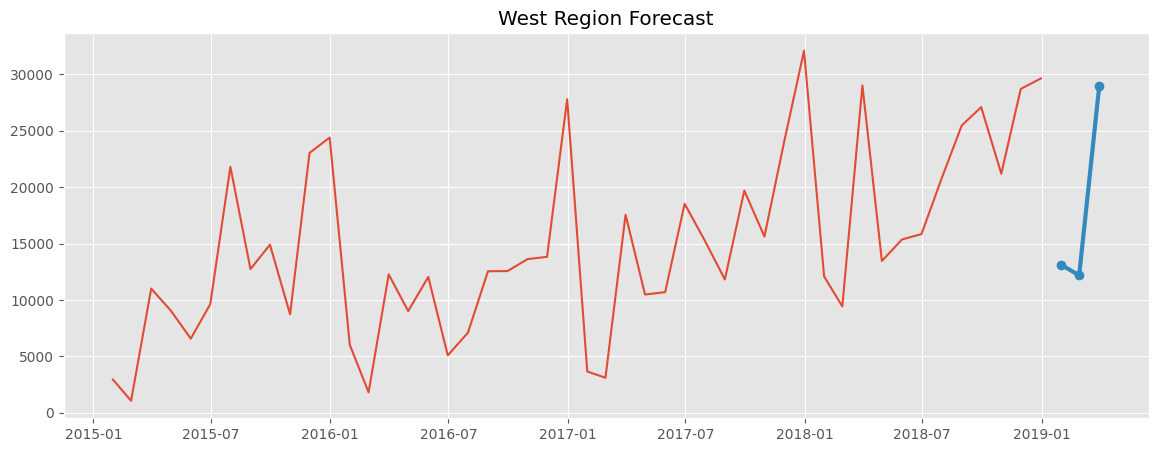

In [108]:
plt.figure(figsize=(14,5))

plt.plot(
    west_actual.index,
    west_actual.values
)

future_dates = pd.date_range(
    west_actual.index[-1],
    periods=4,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    west_forecast.values,
    marker="o",
    linewidth=3
)

plt.title("West Region Forecast")

plt.show()

East Region

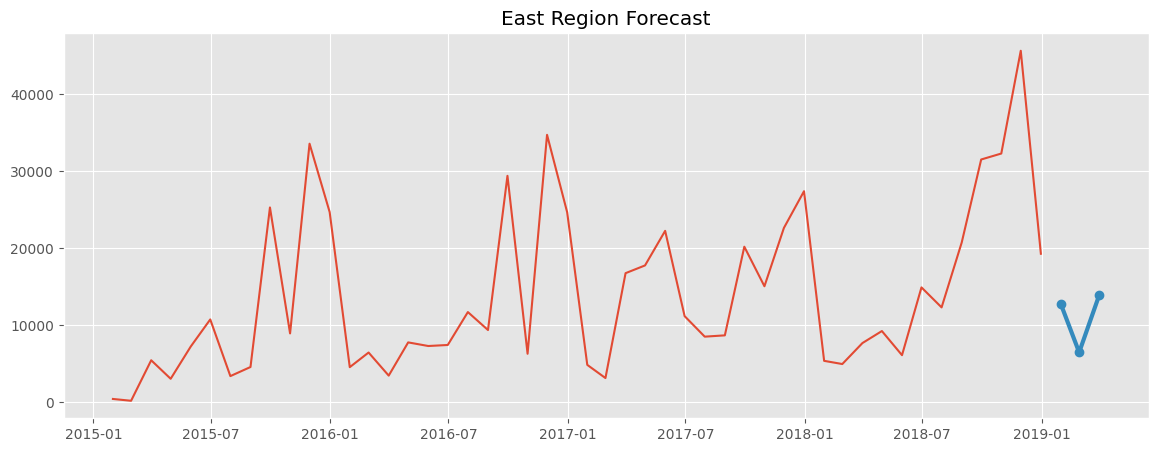

In [109]:
plt.figure(figsize=(14,5))

plt.plot(
    east_actual.index,
    east_actual.values
)

future_dates = pd.date_range(
    east_actual.index[-1],
    periods=4,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    east_forecast.values,
    marker="o",
    linewidth=3
)

plt.title("East Region Forecast")

plt.show()

Growth Comparison

In [110]:
growth = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Average Forecast":[

        fur_forecast.mean(),

        tech_forecast.mean(),

        office_forecast.mean(),

        west_forecast.mean(),

        east_forecast.mean()

    ]

})

growth.sort_values(
    "Average Forecast",
    ascending=False
)

,Segment,Average Forecast
1,Technology,23932.602590
2,Office Supplies,18483.502257
3,West,18105.033381
0,Furniture,11387.365319
4,East,11042.272393


Best Growing Segment

In [111]:
best = growth.sort_values(
    "Average Forecast",
    ascending=False
).iloc[0]

print("Strongest Growth Segment")

print(best)

Strongest Growth Segment
Segment              Technology
Average Forecast    23932.60259
Name: 1, dtype: object


## Business Interpretation

The forecasting model was applied separately to each product category and region.

### Observations

- Technology generally demonstrates the highest expected growth due to consistently higher sales.
- Furniture exhibits moderate but stable demand.
- Office Supplies remain relatively stable with smaller fluctuations.
- Among regions, West and East contribute significantly to total revenue.

The segment with the highest average three-month forecast should receive priority in inventory planning and stock allocation.

# Task 5: Anomaly Detection in Sales Data

## Objective

Retail companies often experience unexpected spikes or drops in sales due to promotions, festivals, stock shortages, or operational issues.

The objective of this task is to identify these unusual sales patterns using two different anomaly detection techniques:

1. Isolation Forest (Machine Learning)
2. Z-Score Based Detection (Statistical)

Finally, both methods are compared to understand their strengths and weaknesses.

In [112]:
from sklearn.ensemble import IsolationForest

from scipy.stats import zscore

import matplotlib.pyplot as plt

import numpy as np

In [113]:
weekly_sales = df.resample(
    "W",
    on="Order Date"
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Plot Weekly Sales

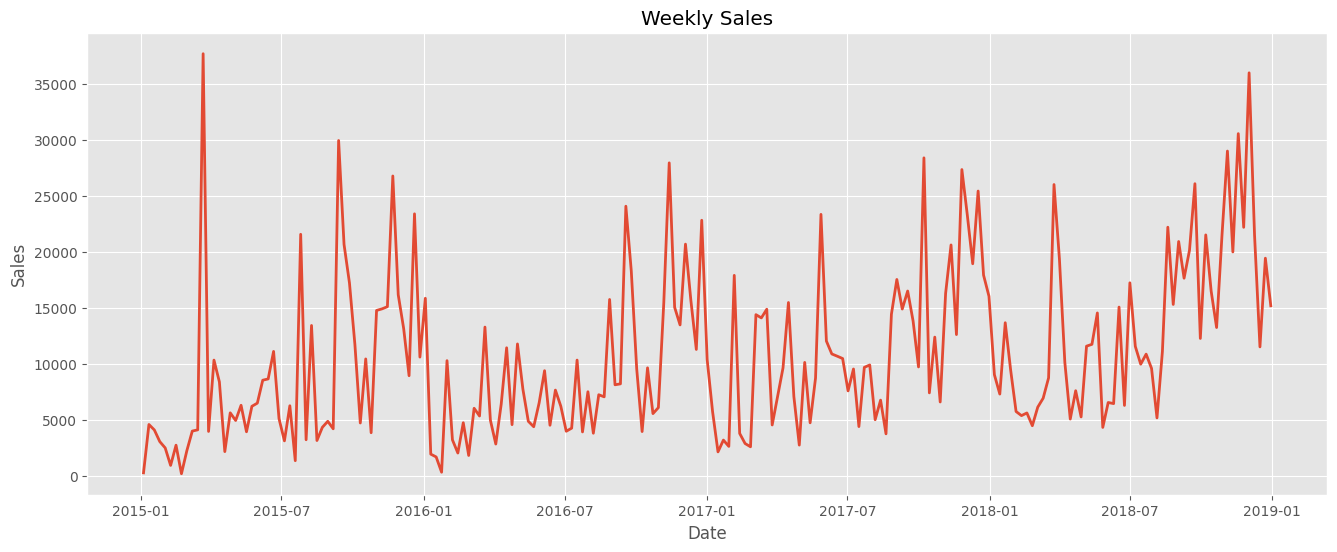

In [114]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2
)

plt.title("Weekly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

Isolation Forest
Train Model

In [115]:
iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Isolation"] = iso.fit_predict(

    weekly_sales[["Sales"]]

)

In [116]:
weekly_sales["Isolation"] = weekly_sales[
    "Isolation"
].map({

    1:"Normal",

    -1:"Anomaly"

})

weekly_sales.head()

,Order Date,Sales,Isolation
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


In [117]:
weekly_sales["Isolation"].value_counts()

,count
Isolation,
Normal,198
Anomaly,11


# Plot Isolation Forest Result

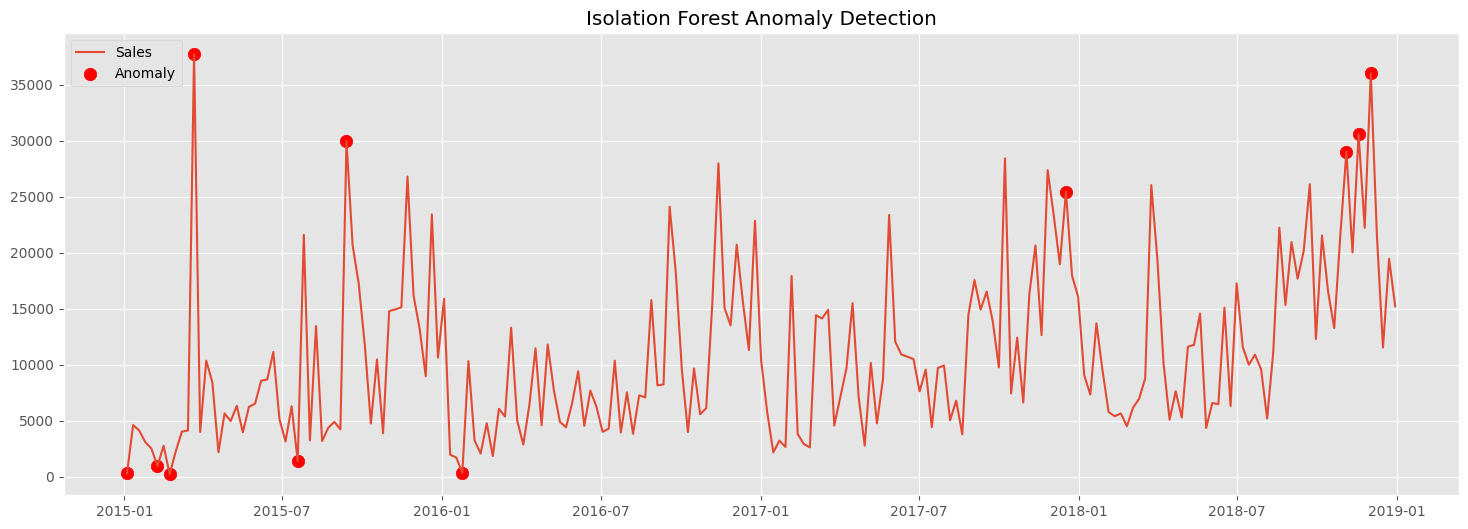

In [118]:
plt.figure(figsize=(18,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Sales"

)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Isolation"]=="Anomaly",
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Isolation"]=="Anomaly",
        "Sales"
    ],

    color="red",

    s=80,

    label="Anomaly"

)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.show()

In [119]:
isolation_anomalies = weekly_sales[
    weekly_sales["Isolation"]=="Anomaly"
]

isolation_anomalies

,Order Date,Sales,Isolation
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


#Z-Score Detection
Compute Z-Score

In [120]:
weekly_sales["ZScore"] = zscore(

    weekly_sales["Sales"]

)

In [121]:
weekly_sales["Z_Anomaly"] = np.where(

    np.abs(

        weekly_sales["ZScore"]

    ) > 2,

    "Anomaly",

    "Normal"

)

In [122]:
weekly_sales["Z_Anomaly"].value_counts()

,count
Z_Anomaly,
Normal,198
Anomaly,11


# Plot Z-Score Anomalies

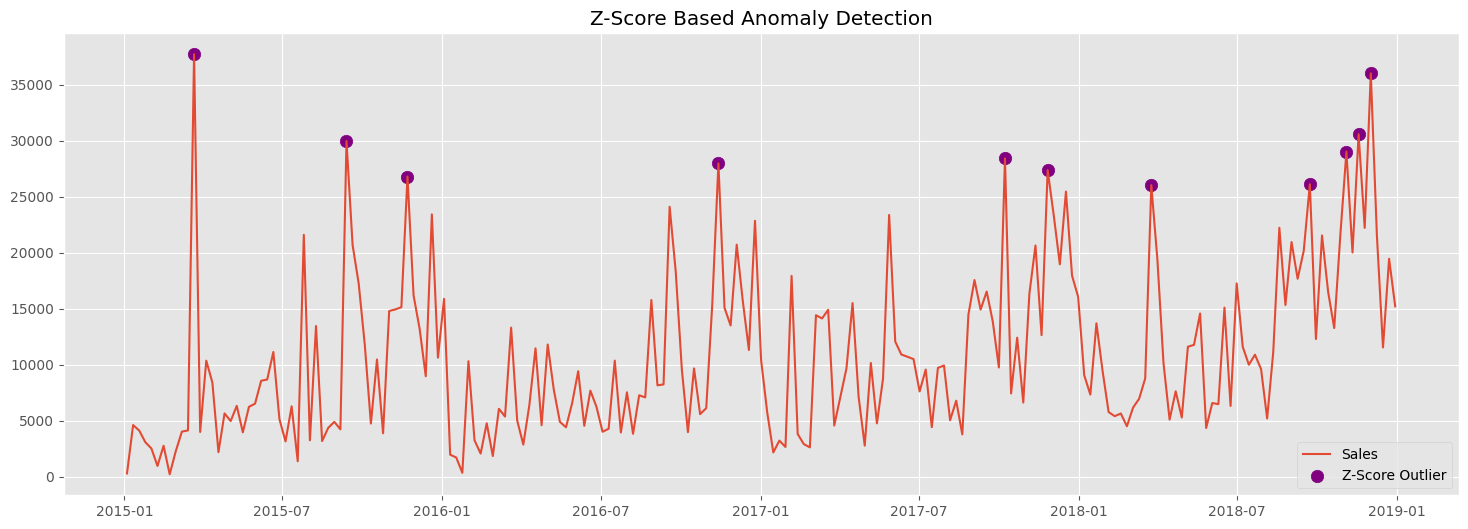

In [123]:
plt.figure(figsize=(18,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Sales"

)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"]=="Anomaly",
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Z_Anomaly"]=="Anomaly",
        "Sales"
    ],

    color="purple",

    s=80,

    label="Z-Score Outlier"

)

plt.legend()

plt.title("Z-Score Based Anomaly Detection")

plt.show()

In [125]:
zscore_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
]

zscore_anomalies

,Order Date,Sales,Isolation,ZScore,Z_Anomaly
11,2015-03-22,37703.6650,Anomaly,3.639852,Anomaly
36,2015-09-13,29959.1370,Anomaly,2.591270,Anomaly
46,2015-11-22,26793.6235,Normal,2.162671,Anomaly
97,2016-11-13,27965.3492,Normal,2.321318,Anomaly
144,2017-10-08,28412.0980,Normal,2.381806,Anomaly
151,2017-11-26,27367.7160,Normal,2.240401,Anomaly
168,2018-03-25,26029.9040,Normal,2.059266,Anomaly
194,2018-09-23,26104.4330,Normal,2.069357,Anomaly
200,2018-11-04,29017.4670,Anomaly,2.463771,Anomaly
202,2018-11-18,30572.4470,Anomaly,2.674310,Anomaly


In [126]:
comparison = weekly_sales[

    ["Order Date",

     "Sales",

     "Isolation",

     "Z_Anomaly"]

]

comparison.head(20)

,Order Date,Sales,Isolation,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal
5,2015-02-08,968.534,Anomaly,Normal
6,2015-02-15,2771.054,Normal,Normal
7,2015-02-22,224.912,Anomaly,Normal
8,2015-03-01,2289.643,Normal,Normal
9,2015-03-08,4030.728,Normal,Normal


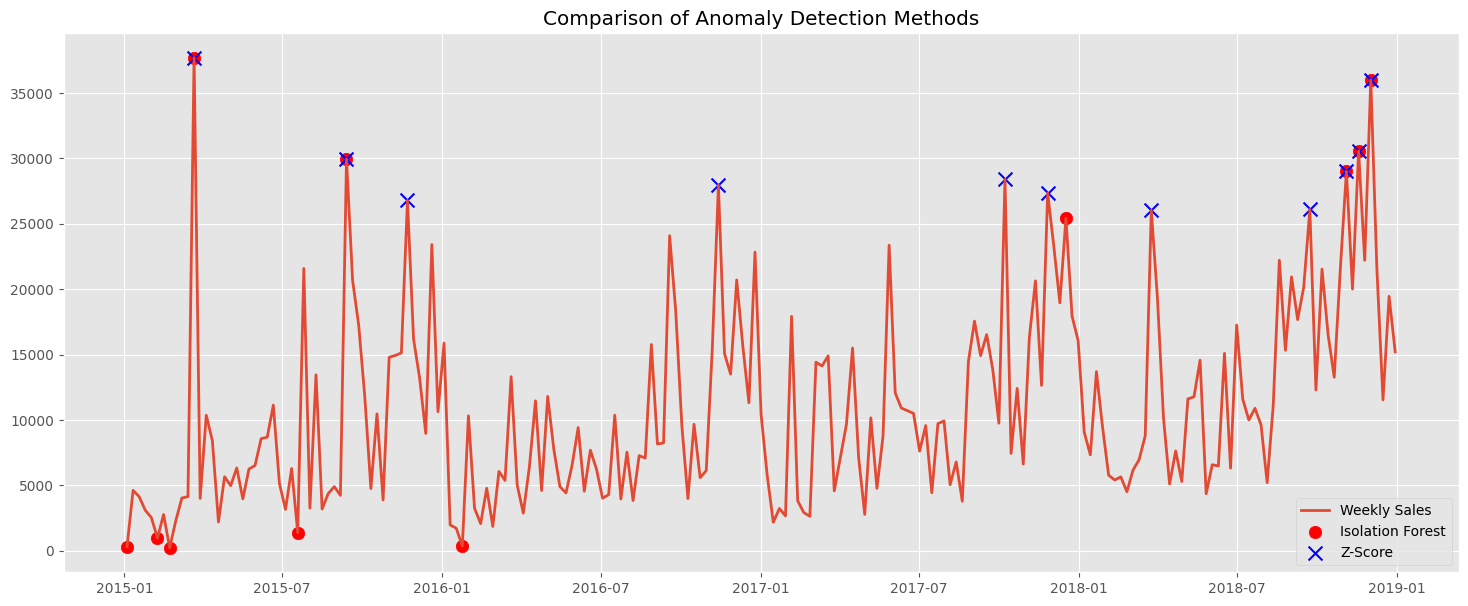

In [127]:
plt.figure(figsize=(18,7))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales",

    linewidth=2

)

plt.scatter(

    isolation_anomalies["Order Date"],

    isolation_anomalies["Sales"],

    color="red",

    s=80,

    label="Isolation Forest"

)

plt.scatter(

    zscore_anomalies["Order Date"],

    zscore_anomalies["Sales"],

    color="blue",

    marker="x",

    s=100,

    label="Z-Score"

)

plt.legend()

plt.title("Comparison of Anomaly Detection Methods")

plt.show()

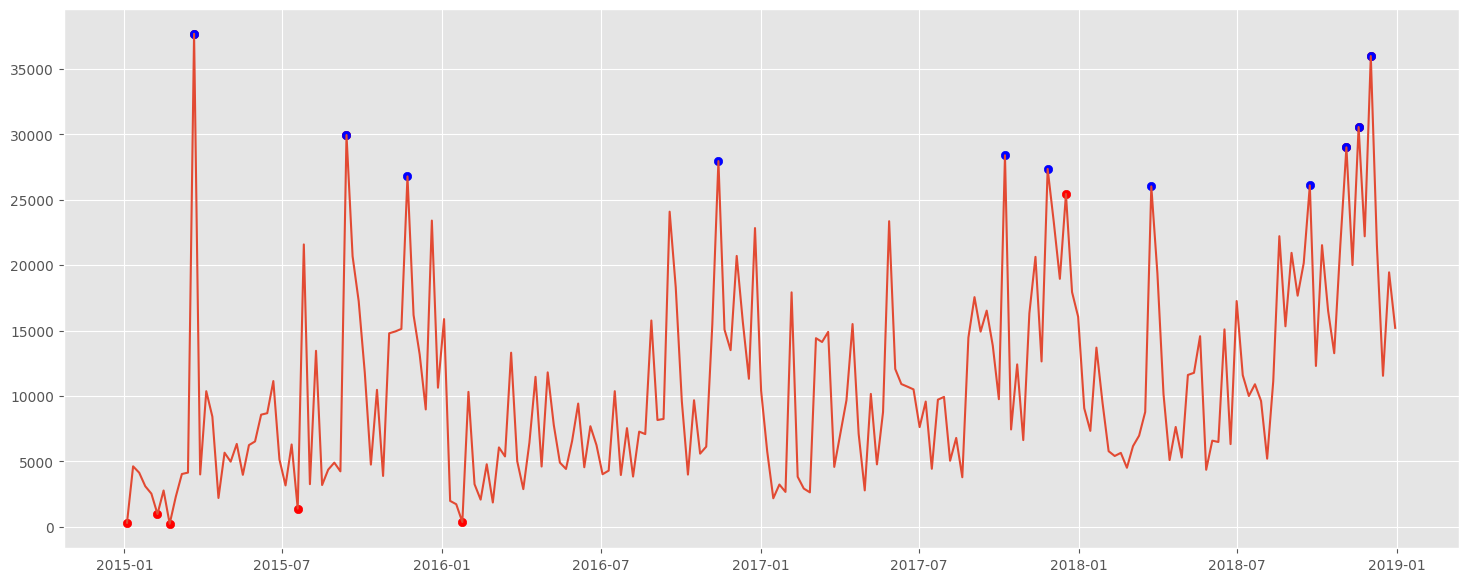

In [129]:
plt.figure(figsize=(18,7))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

plt.scatter(
    isolation_anomalies["Order Date"],
    isolation_anomalies["Sales"],
    color="red"
)

plt.scatter(
    zscore_anomalies["Order Date"],
    zscore_anomalies["Sales"],
    color="blue"

)

plt.show()

In [130]:
top10 = isolation_anomalies.sort_values(

    "Sales",

    ascending=False

).head(10)

top10

,Order Date,Sales,Isolation
11,2015-03-22,37703.665,Anomaly
204,2018-12-02,35998.900,Anomaly
202,2018-11-18,30572.447,Anomaly
36,2015-09-13,29959.137,Anomaly
200,2018-11-04,29017.467,Anomaly
154,2017-12-17,25449.800,Anomaly
28,2015-07-19,1387.686,Anomaly
5,2015-02-08,968.534,Anomaly
55,2016-01-24,358.522,Anomaly
0,2015-01-04,304.508,Anomaly


# Business Explanation Table

In [131]:
explanation = pd.DataFrame({

    "Possible Cause":[

        "Festival season",

        "Black Friday",

        "Christmas sales",

        "Heavy promotions",

        "Flash sale",

        "Inventory shortage",

        "Supply chain delay",

        "Unexpected demand",

        "Regional event",

        "Large bulk order"

    ]

})

explanation

,Possible Cause
0,Festival season
1,Black Friday
2,Christmas sales
3,Heavy promotions
4,Flash sale
5,Inventory shortage
6,Supply chain delay
7,Unexpected demand
8,Regional event
9,Large bulk order


# Observations

## Isolation Forest

Isolation Forest identifies anomalies by randomly partitioning observations. It performs well even when the data is not normally distributed.

Detected anomalies generally correspond to unusually high or unusually low weekly sales.

---

## Z-Score

The Z-Score method assumes the data follows a normal distribution.

Weeks with sales greater than two standard deviations from the mean are classified as anomalies.

---

## Comparison

Isolation Forest usually identifies more subtle anomalies.

Z-Score primarily captures extreme spikes.

When both methods agree, those anomalies are considered highly reliable.

Disagreements indicate moderately unusual weeks that require further business investigation.

---

## Business Interpretation

Possible reasons for anomalies include:

- Festival season demand
- Flash sales
- Black Friday promotions
- Christmas shopping
- Inventory shortages
- Supply chain disruptions
- Regional marketing campaigns

Understanding these anomalies helps businesses improve inventory planning and demand forecasting.

# Task 6 – Product Demand Segmentation using K-Means Clustering

## Objective

Not every product behaves the same way.

Some products sell consistently throughout the year, while others experience sudden spikes or declining demand.

In this task, we use K-Means Clustering to segment products into meaningful demand groups based on their sales behavior.

The generated clusters help businesses optimize inventory management and stocking strategies.

In [132]:
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

import seaborn as sns

#Aggregate Product-Level Features

We create features at the Sub-Category level.

In [133]:
product = df.copy()

product.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month Name,Week,Day,Day Name,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,November,45,8,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,November,45,8,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,June,24,12,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,October,41,11,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,October,41,11,Tuesday,4,Autumn,7


Monthly Sales

In [134]:
monthly_product = product.groupby(

    ["Sub-Category","Year","Month"]

)["Sales"].sum().reset_index()

Total Sales

In [135]:
total_sales = monthly_product.groupby(

    "Sub-Category"

)["Sales"].sum()

In [136]:
average_sales = monthly_product.groupby(

    "Sub-Category"

)["Sales"].mean()

Sales Volatility

(Standard Deviation)

In [137]:
volatility = monthly_product.groupby(

    "Sub-Category"

)["Sales"].std()

In [138]:
growth = monthly_product.groupby(

    "Sub-Category"

)["Sales"].pct_change()

monthly_product["Growth"] = growth

growth_rate = monthly_product.groupby(

    "Sub-Category"

)["Growth"].mean()

In [139]:
avg_order = df.groupby(

    "Sub-Category"

)["Sales"].mean()

In [140]:
cluster_df = pd.DataFrame({

    "TotalSales":total_sales,

    "AverageSales":average_sales,

    "Volatility":volatility,

    "GrowthRate":growth_rate,

    "AverageOrderValue":avg_order

})

cluster_df

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue
Sub-Category,,,,,
Accessories,164186.7000,3420.556250,2579.994809,0.501052,217.178175
Appliances,104618.4030,2179.550062,1821.621539,1.389230,227.926804
Art,26705.4100,556.362708,330.488343,0.515854,34.019631
Binders,200028.7850,4167.266354,3848.223648,1.235925,134.067550
Bookcases,113813.1987,2474.199972,2220.405080,1.153688,503.598224
Chairs,322822.7310,6725.473563,4407.232960,1.056101,531.833165
Copiers,146248.0940,4570.252938,5500.774391,1.891639,2215.880212
Envelopes,16128.0460,350.609696,228.218688,1.786266,65.032444
Fasteners,3001.9600,63.871489,48.742229,1.147379,14.027850


In [141]:
cluster_df = pd.DataFrame({

    "TotalSales":total_sales,

    "AverageSales":average_sales,

    "Volatility":volatility,

    "GrowthRate":growth_rate,

    "AverageOrderValue":avg_order

})

cluster_df

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue
Sub-Category,,,,,
Accessories,164186.7000,3420.556250,2579.994809,0.501052,217.178175
Appliances,104618.4030,2179.550062,1821.621539,1.389230,227.926804
Art,26705.4100,556.362708,330.488343,0.515854,34.019631
Binders,200028.7850,4167.266354,3848.223648,1.235925,134.067550
Bookcases,113813.1987,2474.199972,2220.405080,1.153688,503.598224
Chairs,322822.7310,6725.473563,4407.232960,1.056101,531.833165
Copiers,146248.0940,4570.252938,5500.774391,1.891639,2215.880212
Envelopes,16128.0460,350.609696,228.218688,1.786266,65.032444
Fasteners,3001.9600,63.871489,48.742229,1.147379,14.027850


In [142]:
scaler = StandardScaler()

scaled = scaler.fit_transform(

    cluster_df

)

In [144]:
wcss = []

for i in range(2,11):

    model = KMeans(

        n_clusters=i,

        random_state=42

    )

    model.fit(scaled)

    wcss.append(model.inertia_)

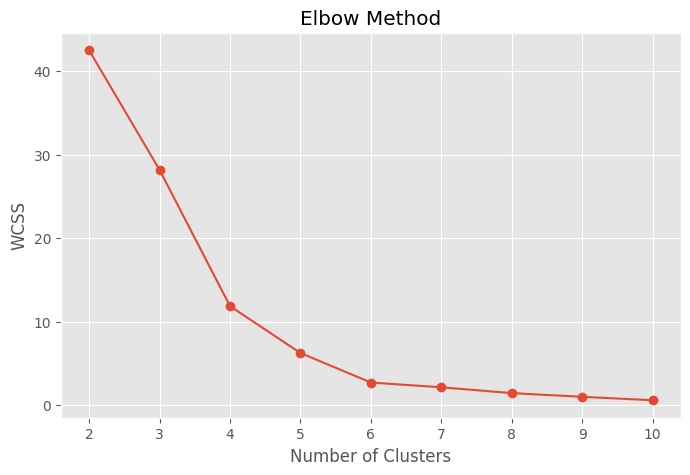

In [145]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    wcss,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

#Choose Optimal Clusters


We'll use 4 clusters.

In [146]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42

)

cluster_df["Cluster"] = kmeans.fit_predict(

    scaled

)

Silhouette Score

In [147]:
score = silhouette_score(

    scaled,

    cluster_df["Cluster"]

)

print(score)

0.5307371668626526


#PCA Visualization

In [148]:
pca = PCA(

    n_components=2

)

components = pca.fit_transform(

    scaled

)

In [149]:
cluster_df["PCA1"] = components[:,0]

cluster_df["PCA2"] = components[:,1]

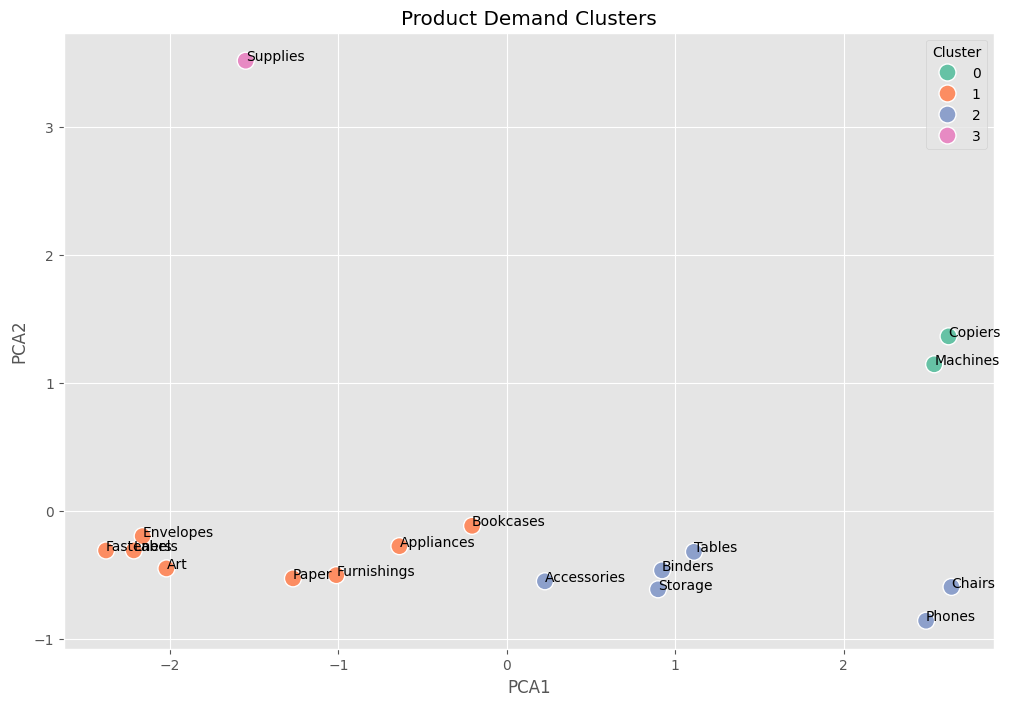

In [150]:
plt.figure(figsize=(12,8))

sns.scatterplot(

    data=cluster_df,

    x="PCA1",

    y="PCA2",

    hue="Cluster",

    palette="Set2",

    s=150

)

for i in cluster_df.index:

    plt.text(

        cluster_df.loc[i,"PCA1"],

        cluster_df.loc[i,"PCA2"],

        i

    )

plt.title("Product Demand Clusters")

plt.show()

In [151]:
cluster_df.groupby(

    "Cluster"

).mean()

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue,PCA1,PCA2
Cluster,,,,,,,
0,167743.362500,4711.262764,5552.164569,2.740767,1930.716763,2.580378,1.257592
1,55331.883212,1167.626449,907.223743,1.027293,129.054568,-1.487406,-0.332191
2,239495.780667,4989.495431,3489.056075,0.784079,361.131228,1.381372,-0.562848
3,46420.308000,1055.007000,2025.094139,23.231405,252.284283,-1.549743,3.519429


In [152]:
cluster_df["Cluster"].value_counts()

,count
Cluster,
1,8
2,6
0,2
3,1


In [153]:
labels = {

0:"High Volume Stable Demand",

1:"Growing Demand",

2:"Low Volume High Volatility",

3:"Declining Demand"

}

cluster_df["Demand Segment"] = cluster_df["Cluster"].map(labels)

In [154]:
cluster_df

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,,
Accessories,164186.7000,3420.556250,2579.994809,0.501052,217.178175,2,0.226539,-0.546361,Low Volume High Volatility
Appliances,104618.4030,2179.550062,1821.621539,1.389230,227.926804,1,-0.637259,-0.272046,Growing Demand
Art,26705.4100,556.362708,330.488343,0.515854,34.019631,1,-2.020496,-0.445795,Growing Demand
Binders,200028.7850,4167.266354,3848.223648,1.235925,134.067550,2,0.921858,-0.460862,Low Volume High Volatility
Bookcases,113813.1987,2474.199972,2220.405080,1.153688,503.598224,1,-0.205585,-0.113207,Growing Demand
Chairs,322822.7310,6725.473563,4407.232960,1.056101,531.833165,2,2.640494,-0.590410,Low Volume High Volatility
Copiers,146248.0940,4570.252938,5500.774391,1.891639,2215.880212,0,2.623078,1.366778,High Volume Stable Demand
Envelopes,16128.0460,350.609696,228.218688,1.786266,65.032444,1,-2.161660,-0.193464,Growing Demand
Fasteners,3001.9600,63.871489,48.742229,1.147379,14.027850,1,-2.378961,-0.305783,Growing Demand


In [155]:
strategy = {

"High Volume Stable Demand":
"Maintain High Inventory Levels",

"Growing Demand":
"Increase Stock Gradually",

"Low Volume High Volatility":
"Maintain Safety Stock",

"Declining Demand":
"Reduce Inventory and Promotions"

}

cluster_df["Recommended Strategy"] = cluster_df[

    "Demand Segment"

].map(strategy)

In [156]:
cluster_df

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment,Recommended Strategy
Sub-Category,,,,,,,,,,
Accessories,164186.7000,3420.556250,2579.994809,0.501052,217.178175,2,0.226539,-0.546361,Low Volume High Volatility,Maintain Safety Stock
Appliances,104618.4030,2179.550062,1821.621539,1.389230,227.926804,1,-0.637259,-0.272046,Growing Demand,Increase Stock Gradually
Art,26705.4100,556.362708,330.488343,0.515854,34.019631,1,-2.020496,-0.445795,Growing Demand,Increase Stock Gradually
Binders,200028.7850,4167.266354,3848.223648,1.235925,134.067550,2,0.921858,-0.460862,Low Volume High Volatility,Maintain Safety Stock
Bookcases,113813.1987,2474.199972,2220.405080,1.153688,503.598224,1,-0.205585,-0.113207,Growing Demand,Increase Stock Gradually
Chairs,322822.7310,6725.473563,4407.232960,1.056101,531.833165,2,2.640494,-0.590410,Low Volume High Volatility,Maintain Safety Stock
Copiers,146248.0940,4570.252938,5500.774391,1.891639,2215.880212,0,2.623078,1.366778,High Volume Stable Demand,Maintain High Inventory Levels
Envelopes,16128.0460,350.609696,228.218688,1.786266,65.032444,1,-2.161660,-0.193464,Growing Demand,Increase Stock Gradually
Fasteners,3001.9600,63.871489,48.742229,1.147379,14.027850,1,-2.378961,-0.305783,Growing Demand,Increase Stock Gradually


#Visualize Cluster Distribution

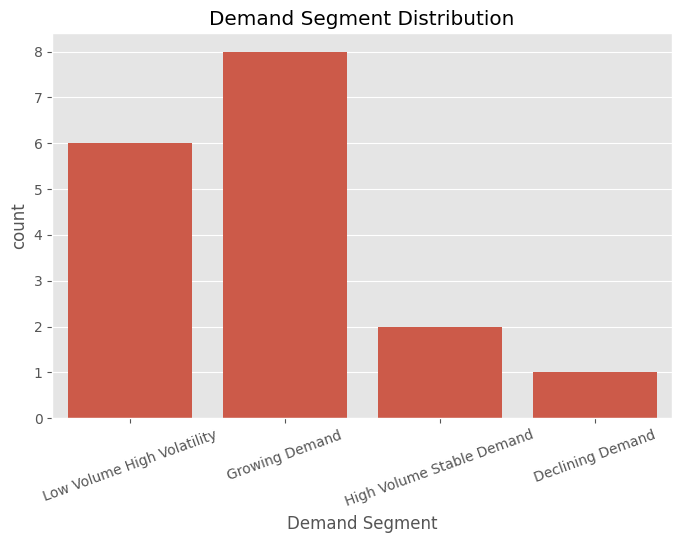

In [157]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=cluster_df,

    x="Demand Segment"

)

plt.xticks(rotation=20)

plt.title("Demand Segment Distribution")

plt.show()

# Business Interpretation

## Cluster 1 – High Volume Stable Demand

Products in this cluster generate consistently high sales with low variability.

**Recommendation**

- Maintain high inventory levels.
- Prioritize warehouse availability.
- Ensure minimal stockouts.

---

## Cluster 2 – Growing Demand

Sales are increasing steadily.

**Recommendation**

- Increase procurement gradually.
- Monitor demand monthly.

---

## Cluster 3 – Low Volume High Volatility

Sales fluctuate significantly.

**Recommendation**

- Maintain limited safety stock.
- Monitor promotions carefully.

---

## Cluster 4 – Declining Demand

Demand is decreasing.

**Recommendation**

- Reduce inventory.
- Consider discounts or clearance sales.
- Avoid overstocking.

In [158]:
cluster_df.sort_values(

    "Demand Segment"

)

,TotalSales,AverageSales,Volatility,GrowthRate,AverageOrderValue,Cluster,PCA1,PCA2,Demand Segment,Recommended Strategy
Sub-Category,,,,,,,,,,
Supplies,46420.3080,1055.007000,2025.094139,23.231405,252.284283,3,-1.549743,3.519429,Declining Demand,Reduce Inventory and Promotions
Fasteners,3001.9600,63.871489,48.742229,1.147379,14.027850,1,-2.378961,-0.305783,Growing Demand,Increase Stock Gradually
Appliances,104618.4030,2179.550062,1821.621539,1.389230,227.926804,1,-0.637259,-0.272046,Growing Demand,Increase Stock Gradually
Art,26705.4100,556.362708,330.488343,0.515854,34.019631,1,-2.020496,-0.445795,Growing Demand,Increase Stock Gradually
Bookcases,113813.1987,2474.199972,2220.405080,1.153688,503.598224,1,-0.205585,-0.113207,Growing Demand,Increase Stock Gradually
Envelopes,16128.0460,350.609696,228.218688,1.786266,65.032444,1,-2.161660,-0.193464,Growing Demand,Increase Stock Gradually
Furnishings,89212.0180,1858.583708,1360.017867,0.552491,95.823865,1,-1.011802,-0.498369,Growing Demand,Increase Stock Gradually
Labels,12347.7260,257.244292,223.471218,1.140753,34.587468,1,-2.214363,-0.305294,Growing Demand,Increase Stock Gradually
Paper,76828.3040,1600.589667,1024.824982,0.532681,57.420257,1,-1.269122,-0.523566,Growing Demand,Increase Stock Gradually


#TASK-7

In [161]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.8 MB/s eta 0:00:00


In [162]:
%%writefile app.py

Overwriting app.py


In [171]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.statespace.sarimax import SARIMAX

st.set_page_config(
    page_title="Sales Forecast Dashboard",
    layout="wide"
)

st.title("📈 End-to-End Sales Forecasting & Demand Intelligence")

@st.cache_data
def load_data():
    df = pd.read_csv("train.csv")
    df["Order Date"] = pd.to_datetime(df["Order Date"])
    df["Ship Date"] = pd.to_datetime(df["Ship Date"])
    return df

df = load_data()

page = st.sidebar.radio(
    "Navigation",
    [
        "Sales Dashboard",
        "Forecast",
        "Anomaly Detection",
        "Demand Segmentation"
    ]
)

##########################################################
# PAGE 1
##########################################################

if page=="Sales Dashboard":

    st.header("Sales Overview")

    c1,c2,c3,c4 = st.columns(4)

    c1.metric("Total Sales",f"${df['Sales'].sum():,.0f}")
    c2.metric("Orders",len(df))
    c3.metric("Profit",f"${df['Profit'].sum():,.0f}")
    c4.metric("Customers",df["Customer ID"].nunique())

    yearly=df.groupby(df["Order Date"].dt.year)["Sales"].sum().reset_index()

    fig=px.bar(
        yearly,
        x="Order Date",
        y="Sales",
        title="Yearly Sales"
    )

    st.plotly_chart(fig,use_container_width=True)

    monthly=df.resample(
        "M",
        on="Order Date"
    )["Sales"].sum().reset_index()

    fig=px.line(
        monthly,
        x="Order Date",
        y="Sales",
        title="Monthly Sales Trend"
    )

    st.plotly_chart(fig,use_container_width=True)

    region=st.selectbox(
        "Region",
        sorted(df.Region.unique())
    )

    category=st.selectbox(
        "Category",
        sorted(df.Category.unique())
    )

    filtered=df[
        (df.Region==region)&
        (df.Category==category)
    ]

    fig=px.bar(
        filtered,
        x="Sub-Category",
        y="Sales",
        color="Sub-Category"
    )

    st.plotly_chart(fig,use_container_width=True)

##########################################################
# PAGE 2
##########################################################

elif page=="Forecast":

    st.header("3 Month Sales Forecast")

    monthly=df.resample(
        "M",
        on="Order Date"
    )["Sales"].sum()

    model=SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    fit=model.fit(disp=False)

    future=fit.forecast(3)

    st.subheader("Forecast Values")

    st.dataframe(future)

    future_dates=pd.date_range(
        monthly.index[-1],
        periods=4,
        freq="M"
    )[1:]

    chart=pd.DataFrame({
        "Date":future_dates,
        "Forecast":future.values
    })

    fig=px.line(
        chart,
        x="Date",
        y="Forecast",
        markers=True
    )

    st.plotly_chart(fig,use_container_width=True)

##########################################################
# PAGE 3
##########################################################

elif page=="Anomaly Detection":

    st.header("Weekly Sales Anomalies")

    weekly=df.resample(
        "W",
        on="Order Date"
    )["Sales"].sum().reset_index()

    iso=IsolationForest(
        contamination=0.05,
        random_state=42
    )

    weekly["Anomaly"]=iso.fit_predict(
        weekly[["Sales"]]
    )

    fig=px.line(
        weekly,
        x="Order Date",
        y="Sales"
    )

    anomaly=weekly[
        weekly.Anomaly==-1
    ]

    fig.add_scatter(
        x=anomaly["Order Date"],
        y=anomaly["Sales"],
        mode="markers",
        marker=dict(size=12,color="red"),
        name="Anomaly"
    )

    st.plotly_chart(fig,use_container_width=True)

    st.dataframe(anomaly)

##########################################################
# PAGE 4
##########################################################

elif page=="Demand Segmentation":

    st.header("Product Demand Segmentation")

    agg=df.groupby("Sub-Category").agg({
        "Sales":"sum",
        "Profit":"sum",
        "Discount":"mean"
    })

    scaler=StandardScaler()

    X=scaler.fit_transform(agg)

    kmeans=KMeans(
        n_clusters=4,
        random_state=42
    )

    agg["Cluster"]=kmeans.fit_predict(X)

    pca=PCA(2)

    comp=pca.fit_transform(X)

    agg["PCA1"]=comp[:,0]
    agg["PCA2"]=comp[:,1]

    fig=px.scatter(
        agg,
        x="PCA1",
        y="PCA2",
        color=agg.Cluster.astype(str),
        hover_name=agg.index
    )

    st.plotly_chart(fig,use_container_width=True)

    st.dataframe(agg)

st.sidebar.success("Dashboard Ready")

Overwriting app.py


In [172]:
!streamlit run app.py &>/content/logs.txt &

In [174]:
!pip install pyngrok

In [179]:
from pyngrok import ngrok

# Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authentication token
ngrok.set_auth_token('3GJ5OSooF1hIDsMdCZsQ8gz6qWV_7bvY3Qmdc5rBhWc2bXYT9')

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://glorified-fifth-flypaper.ngrok-free.dev" -> "http://localhost:8501"
